In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

from qc_empirical import ConnectomeQualityChecker



In [20]:
# Read the CSV file
name = "00_connectomes_50"
path_to_conns = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/{name}.npy"
connectomes = np.load(path_to_conns)
output_folder = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/empirical_data/suarez_MaMI_dataset/qc/qc_{name}")
output_folder.mkdir(parents=True, exist_ok=True)

In [ ]:
# Initialize checker
checker = ConnectomeQualityChecker(connectomes, threshold=None)

# Compute all metrics
checker.compute_all_metrics()

# Print summary
checker.print_summary()


Analyzing 225 connectomes with 100 nodes each...


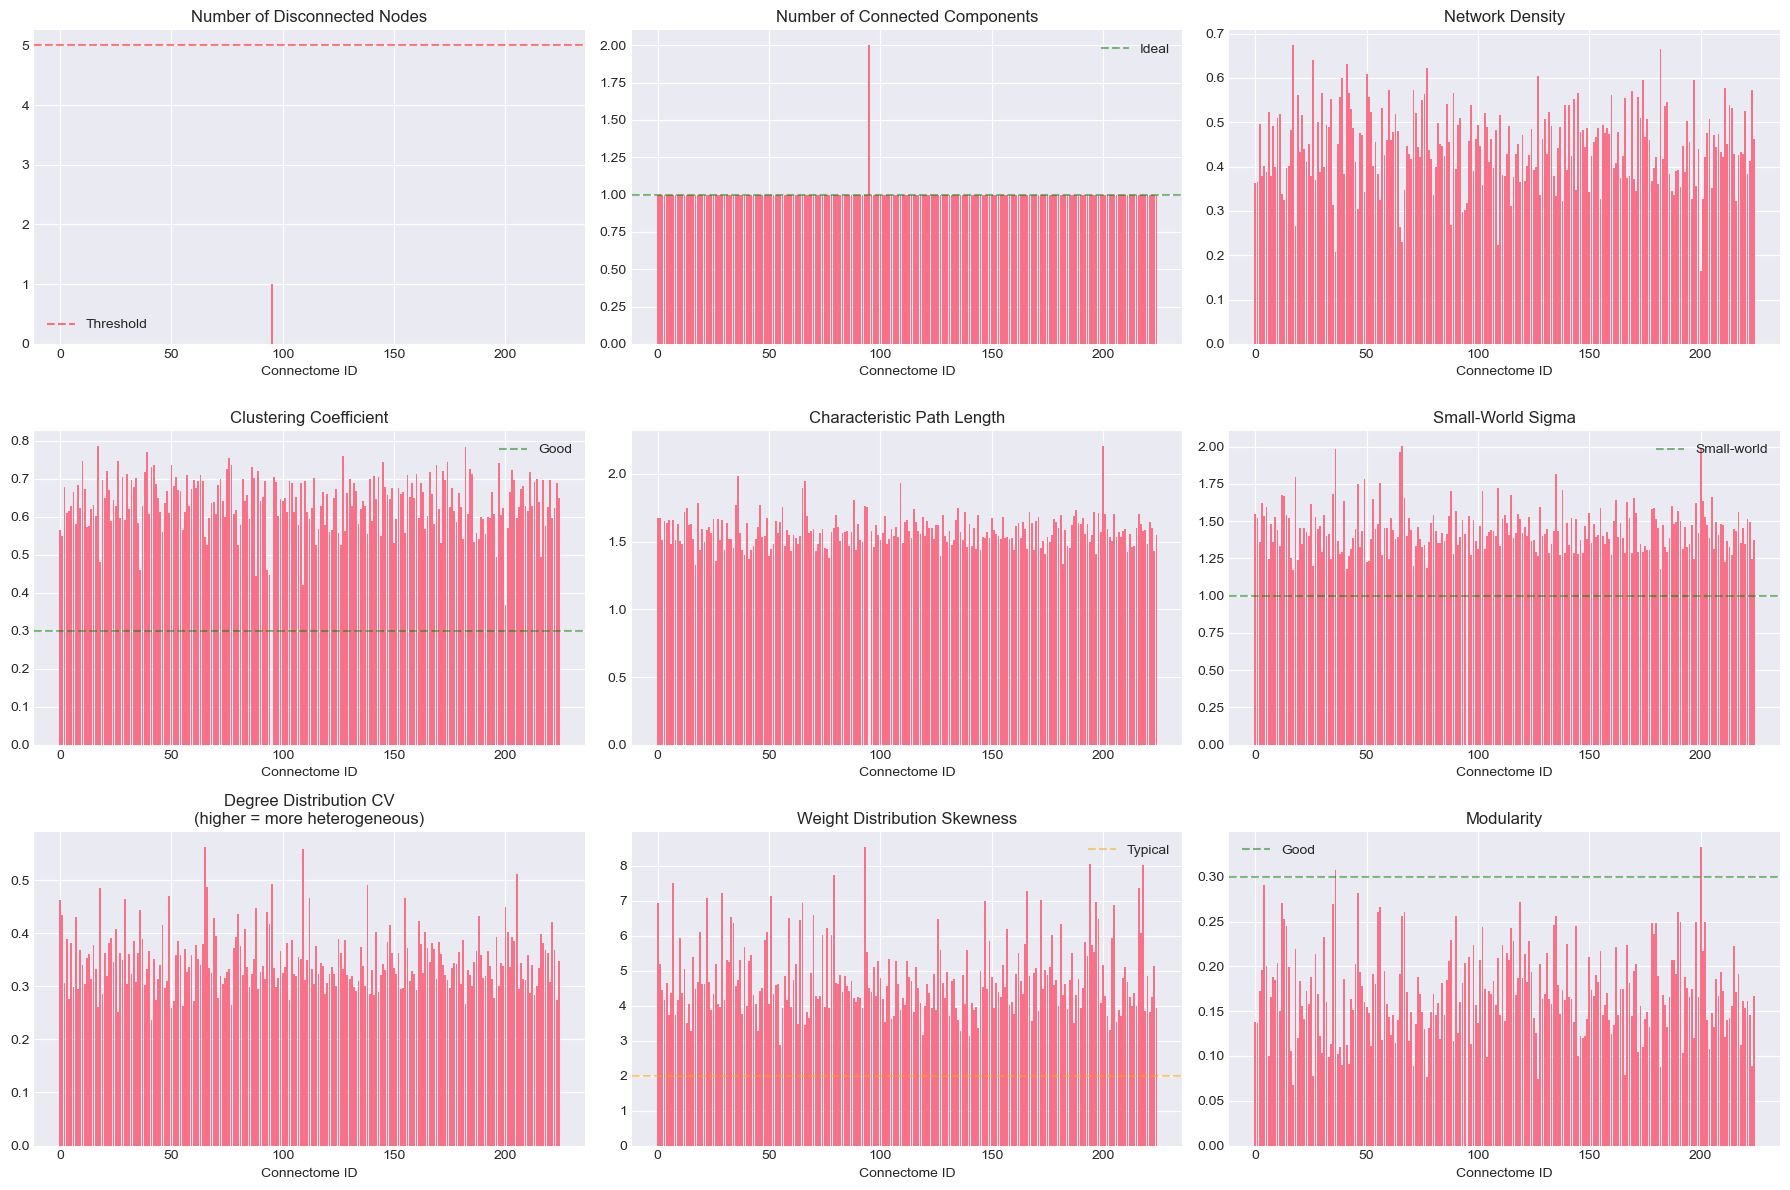

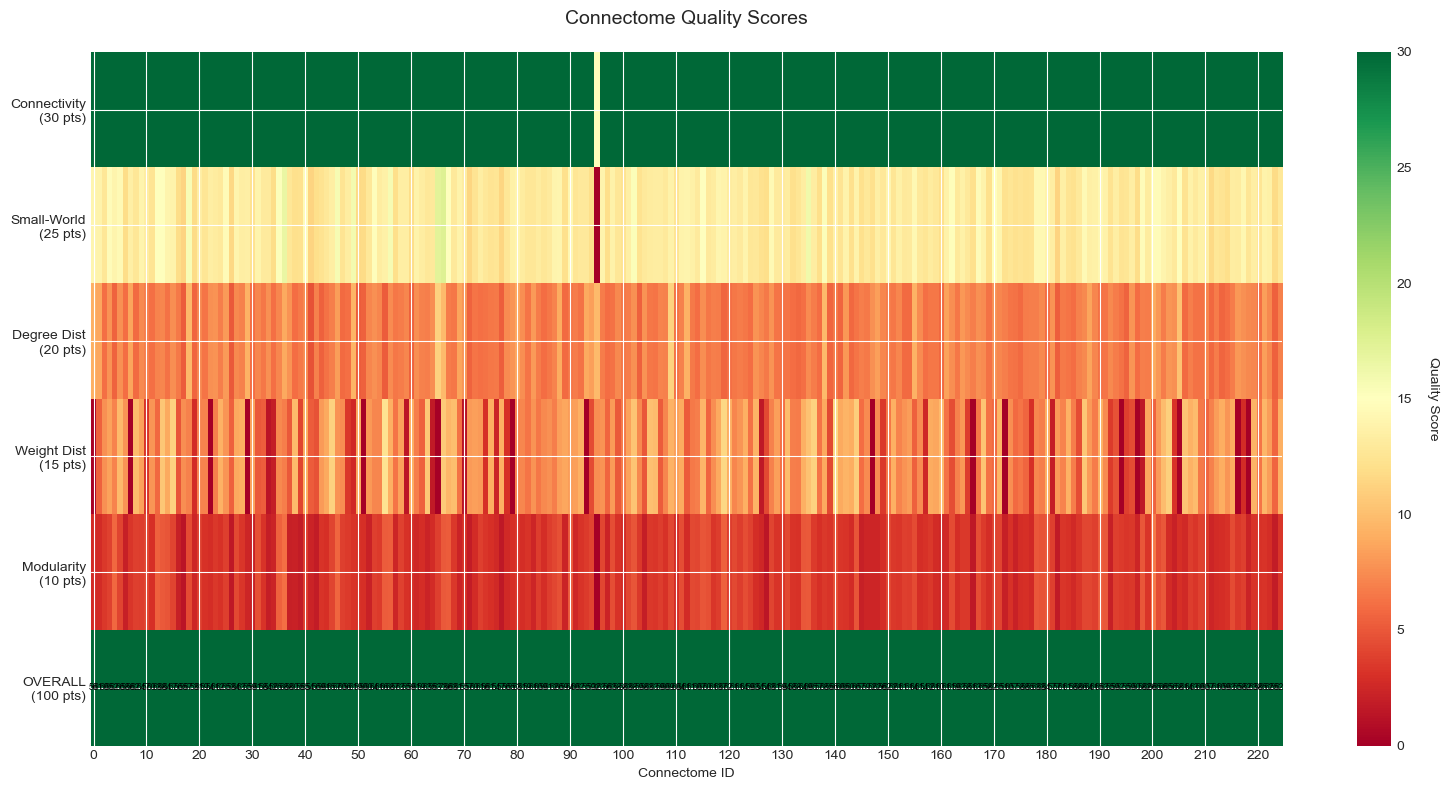

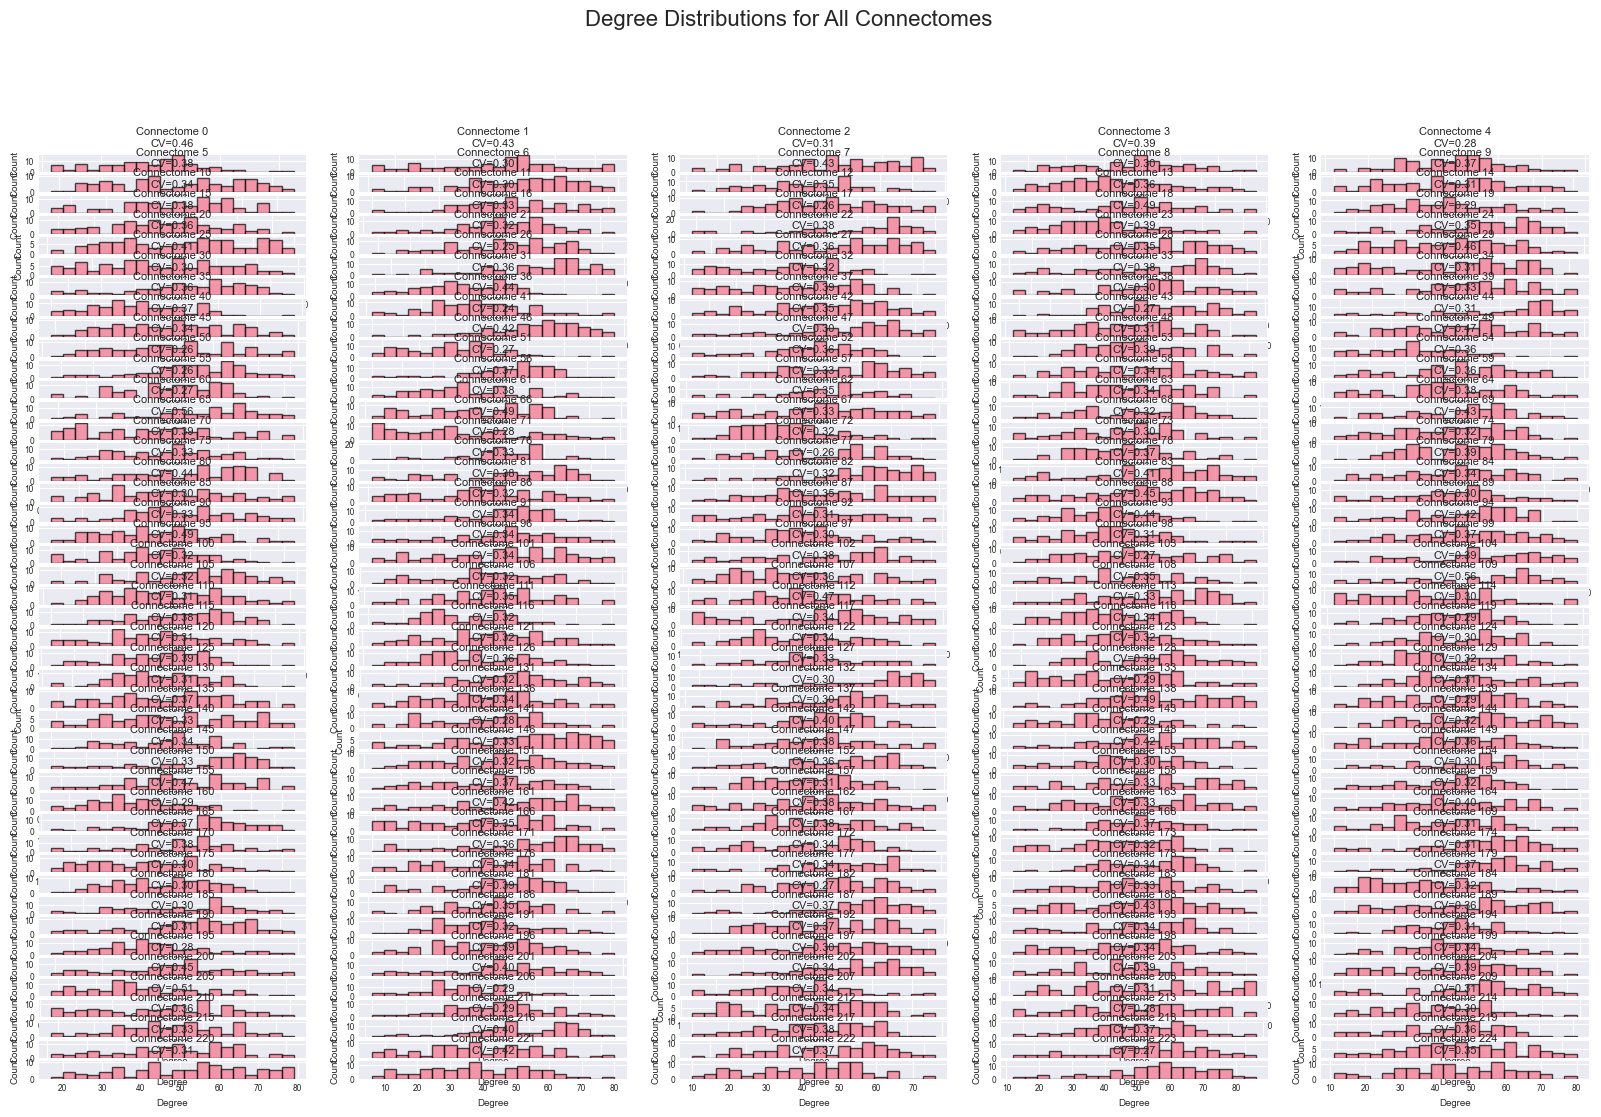

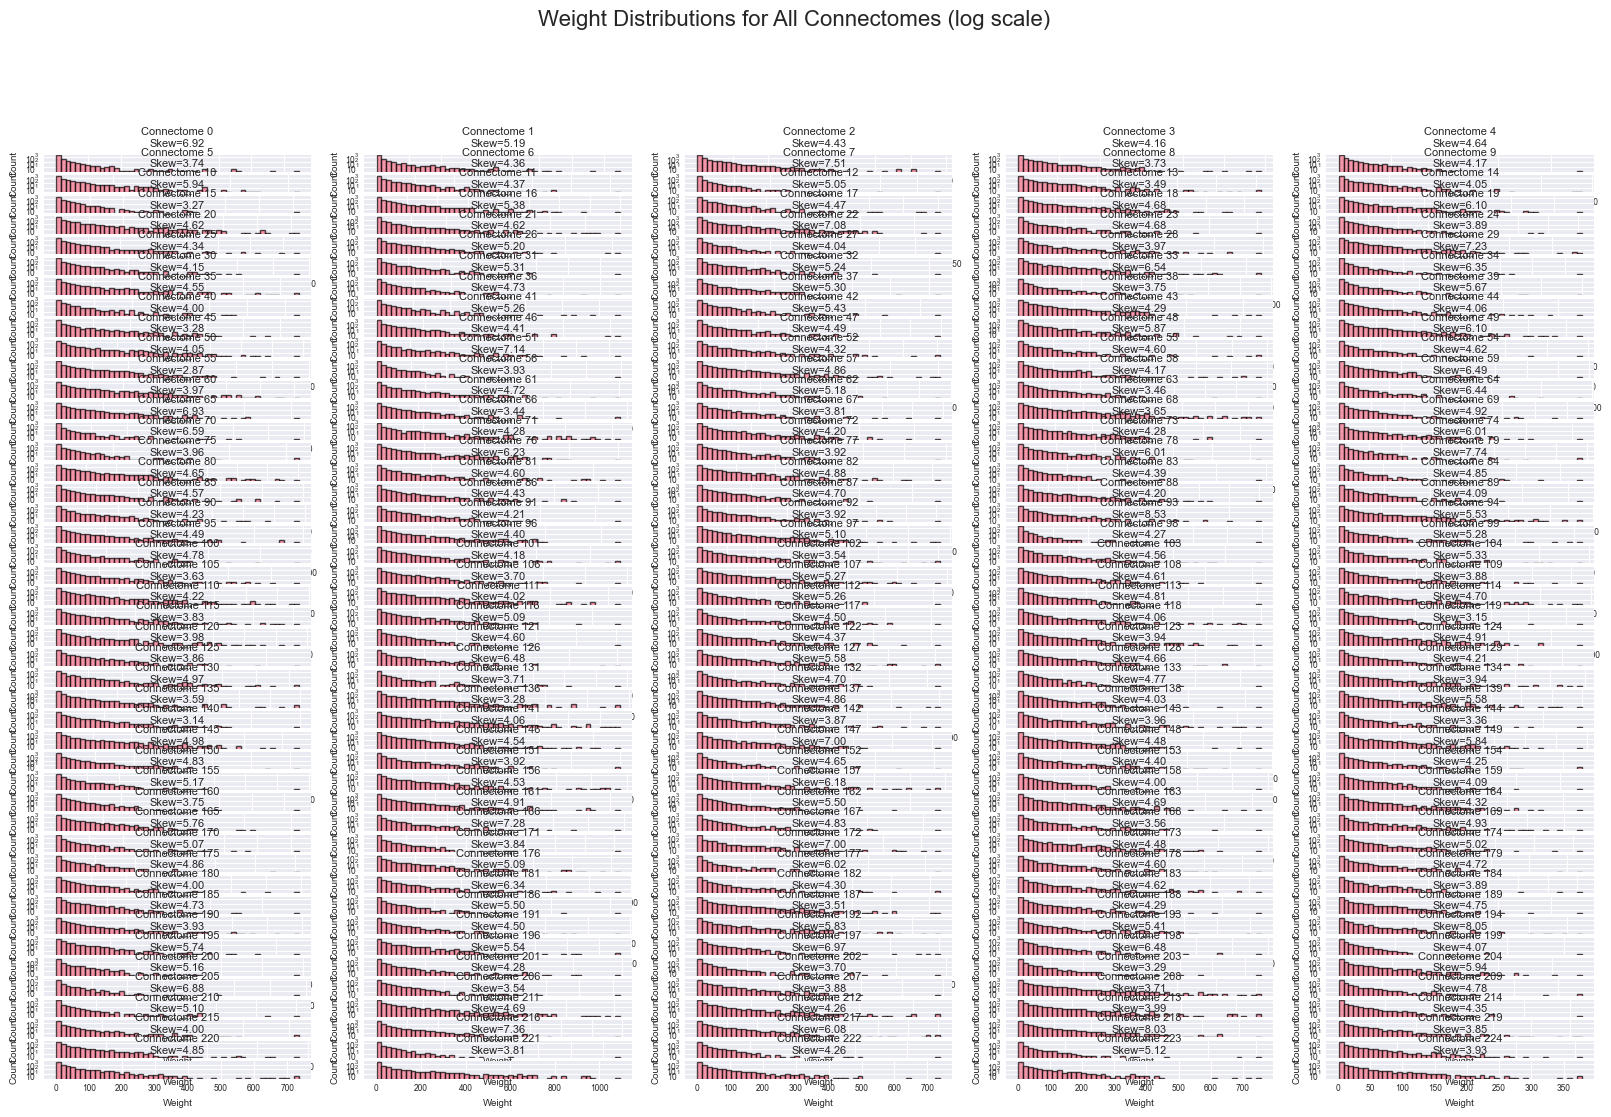

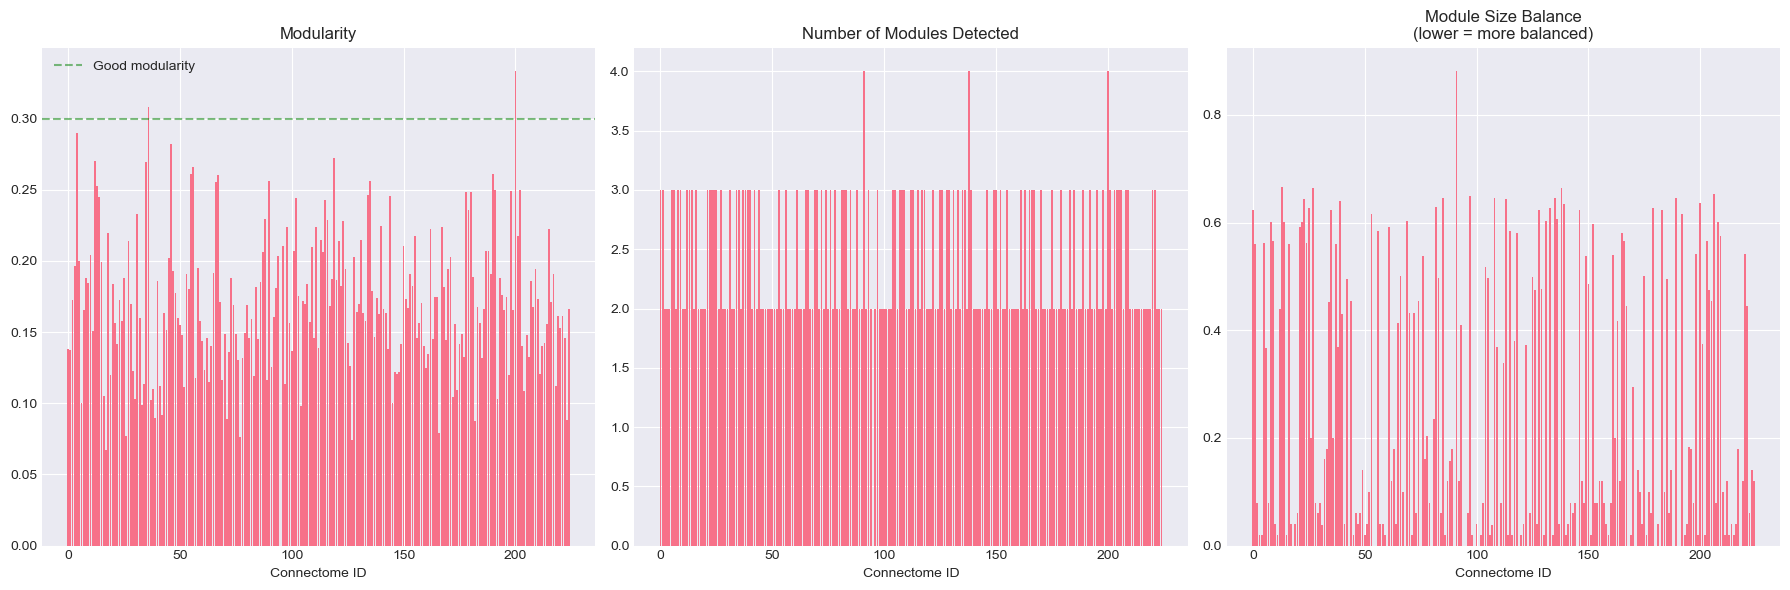

In [ ]:
# Generate plots
fig1 = checker.plot_topology_overview()
fig2 = checker.plot_quality_heatmap()
fig3 = checker.plot_degree_distributions()
fig4 = checker.plot_weight_distributions()
fig5 = checker.plot_modularity_analysis()


In [ ]:
# Get detailed dataframe
df_summary = checker.get_summary_dataframe()
df_summary.to_csv('connectome_quality_summary.csv', index=False)


In [ ]:
# Identify problematic connectomes
problematic = df_summary[df_summary['quality_score'] < 50]
print(f"\nProblematic connectomes: {list(problematic['connectome_id'].values)}")


Problematic connectomes: [np.int64(95)]


In [ ]:
fig1.savefig(output_folder / "fig_1_barplot_topology_overview.pdf")
fig2.savefig(output_folder / "fig_2_quality_heatmap.pdf")
fig3.savefig(output_folder / "fig_3_degree_distributions.pdf")
fig4.savefig(output_folder / "fig_4_weight_distributions.pdf")
fig5.savefig(output_folder / "fig_5_modularity_analysis.pdf")

# Atempt number 2, using previous evaluation of the networks

In [15]:

name = "binarized" # ["binarized", "weighted", "binarized_but_multiplied_with_orig_weights"]

folder_path = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/emprirical_analysis")
df = pd.read_csv(folder_path / f"empirical_analysis_{name}.csv")


df.keys()
#    'avg_communicability',
#    'global_efficiency', 'modularity', 'avg_clustering', 'avg_degree',
#    'density_bct', 'transitivity', 'avg_edge_distance', 'wiring_cost',
#    'char_path_length', 'richclub_n_edges', 'richclub_avg_length',

Index(['subject_id', 'network_index', 'avg_communicability',
       'global_efficiency', 'modularity', 'avg_clustering', 'avg_degree',
       'density_bct', 'transitivity', 'avg_edge_distance', 'wiring_cost',
       'char_path_length', 'richclub_n_edges', 'richclub_avg_length',
       'mc_mean', 'mc_std', 'h_params_density', 'h_params_spectral_radius',
       'h_params_n_lags', 'h_params_train_len', 'h_params_test_len',
       'h_params_n_runs', 'h_params_input_scaling',
       'h_params_regression_method', 'h_params_n_transient',
       'h_params_leak_rate', 'h_params_bias', 'h_params_random_state', 'mc_0',
       'mc_1', 'mc_2', 'mc_3', 'mc_4', 'mc_5', 'mc_6', 'mc_7', 'mc_8', 'mc_9',
       'mc_10', 'mc_11', 'mc_12', 'mc_13', 'mc_14', 'mc_15', 'mc_16', 'mc_17',
       'mc_18', 'mc_19', 'mc_20', 'mc_21', 'mc_22', 'mc_23', 'mc_24', 'mc_25',
       'mc_26', 'mc_27', 'mc_28', 'mc_29', 'mc_30', 'mc_31', 'mc_32', 'mc_33',
       'mc_34', 'mc_35', 'mc_36', 'mc_37', 'mc_38', 'mc_39', 'mc_40'

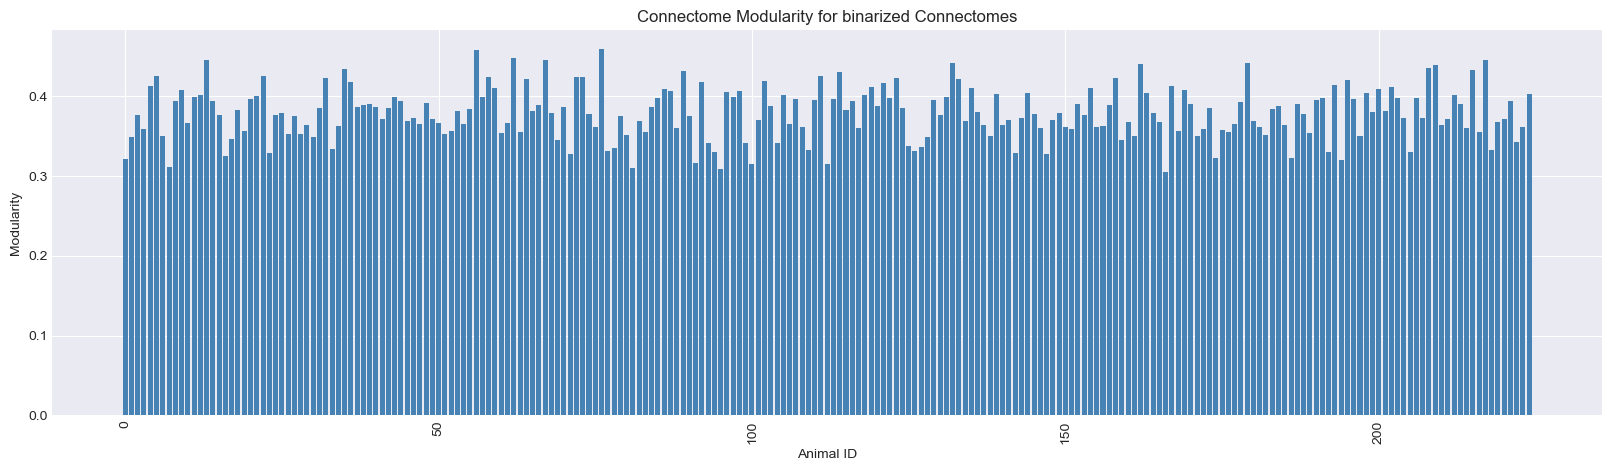

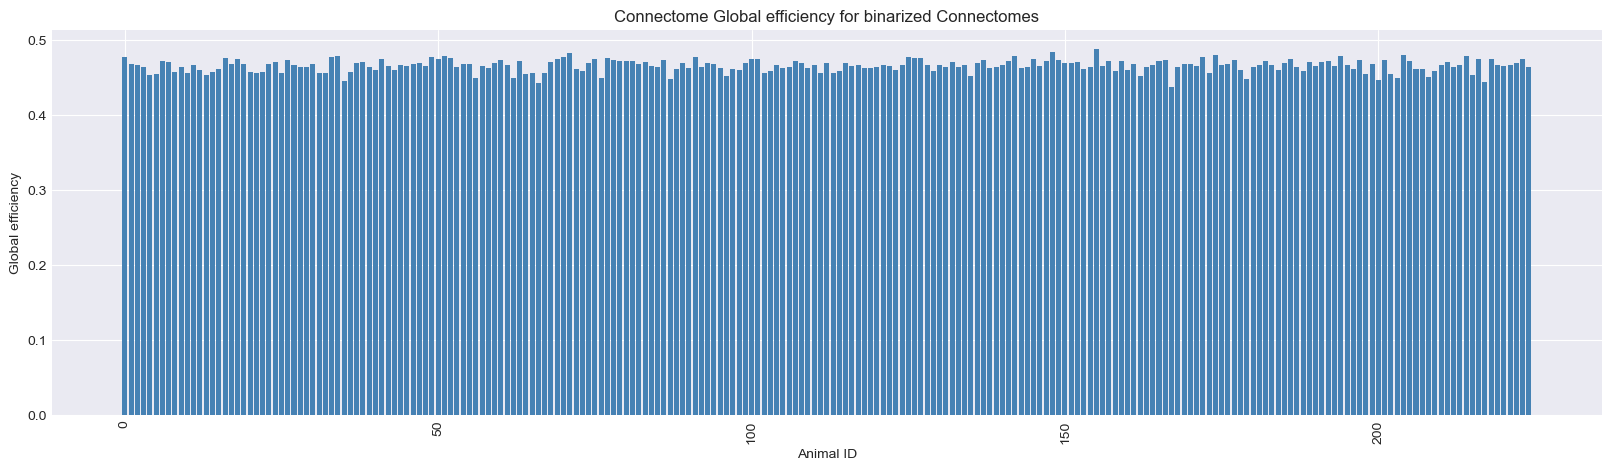

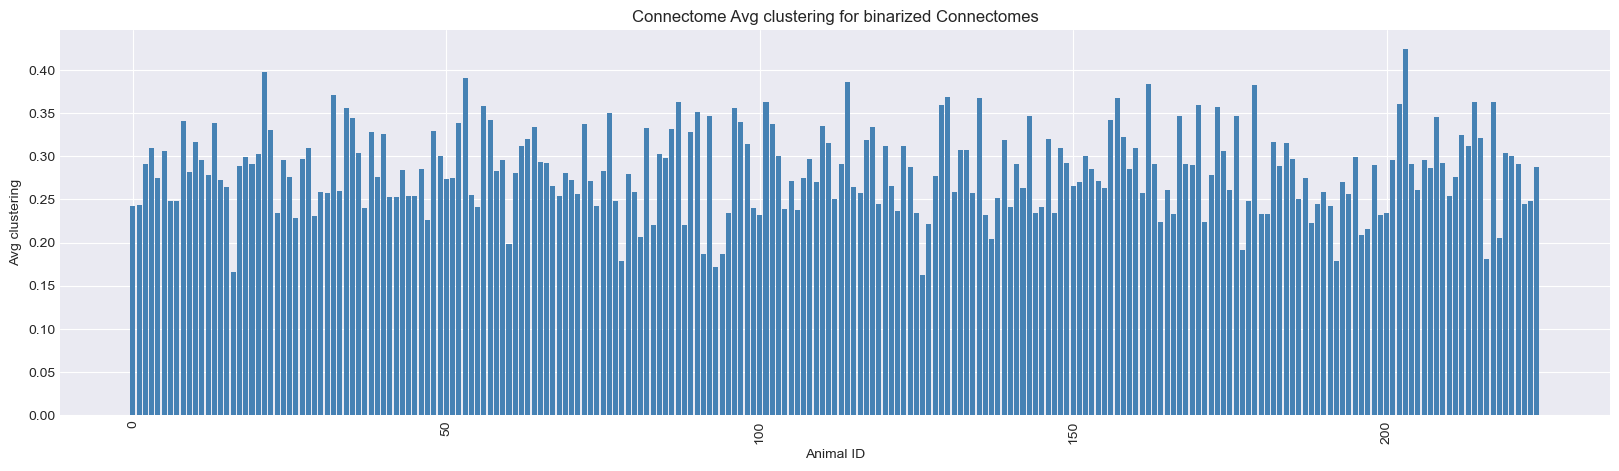

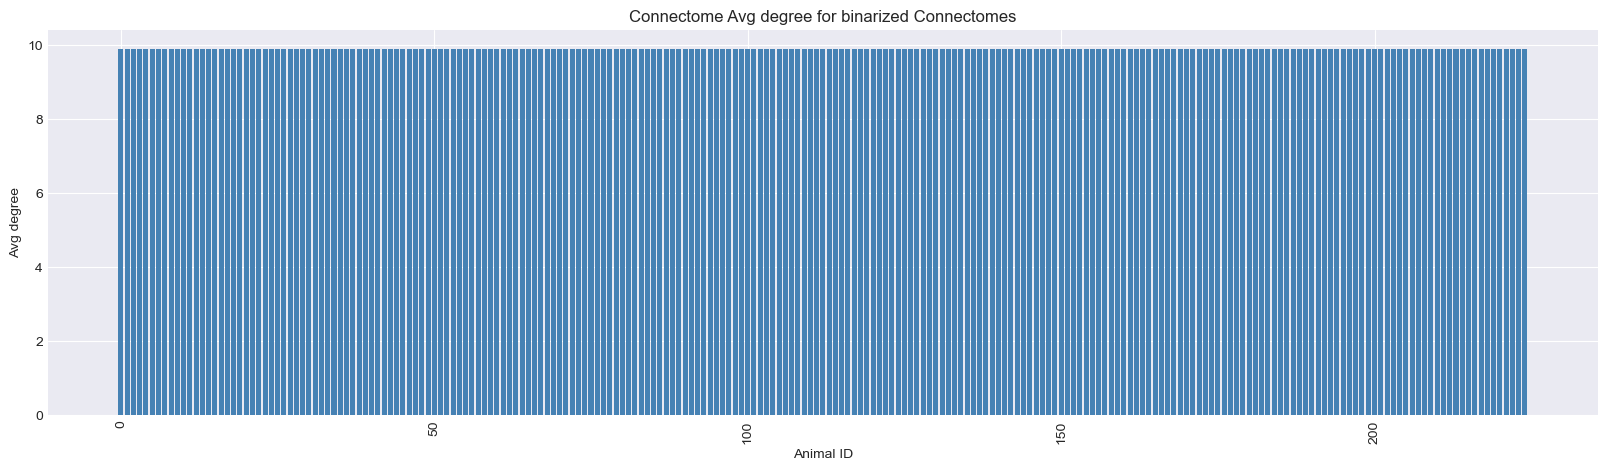

In [20]:
for name_metric in ["modularity", "global_efficiency", "avg_clustering", "avg_degree"]:
    plt.figure(figsize=(20,5)) 
    plt.bar(df['subject_id'], df[name_metric], color='steelblue')
    plt.xlabel('Animal ID')
    plt.ylabel(name_metric.replace('_', ' ').capitalize())
    plt.title(f'Connectome {name_metric.replace('_', ' ').capitalize()} for {name} Connectomes')
    plt.xticks(rotation=90)
    plt.savefig(folder_path / f"{name_metric}_barplot_{name}.pdf")

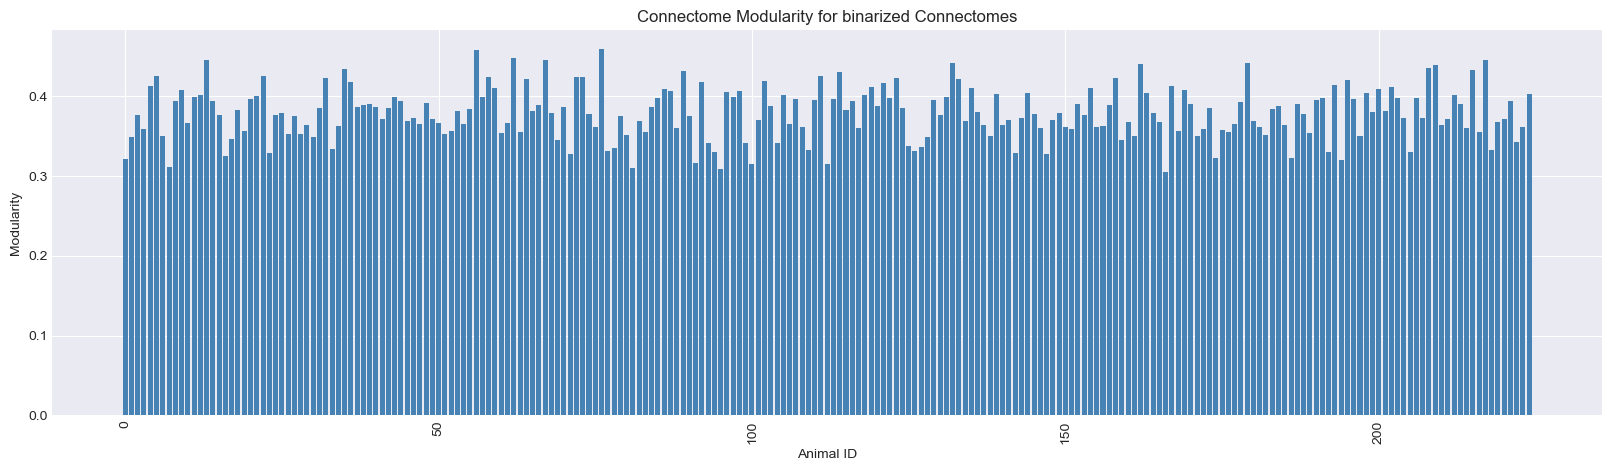

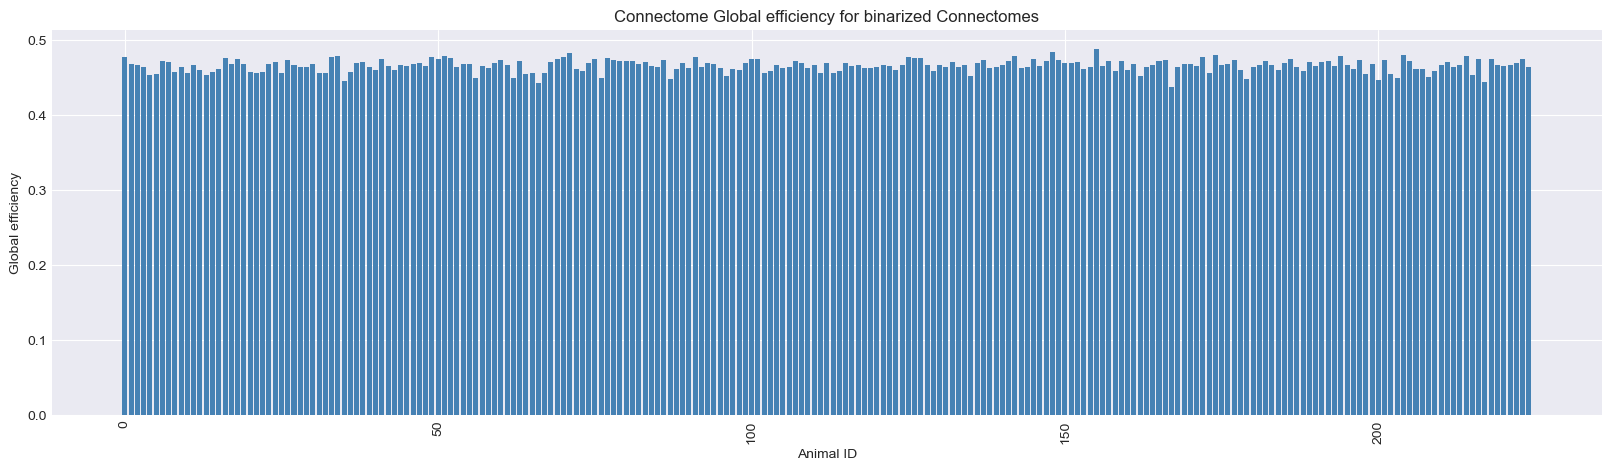

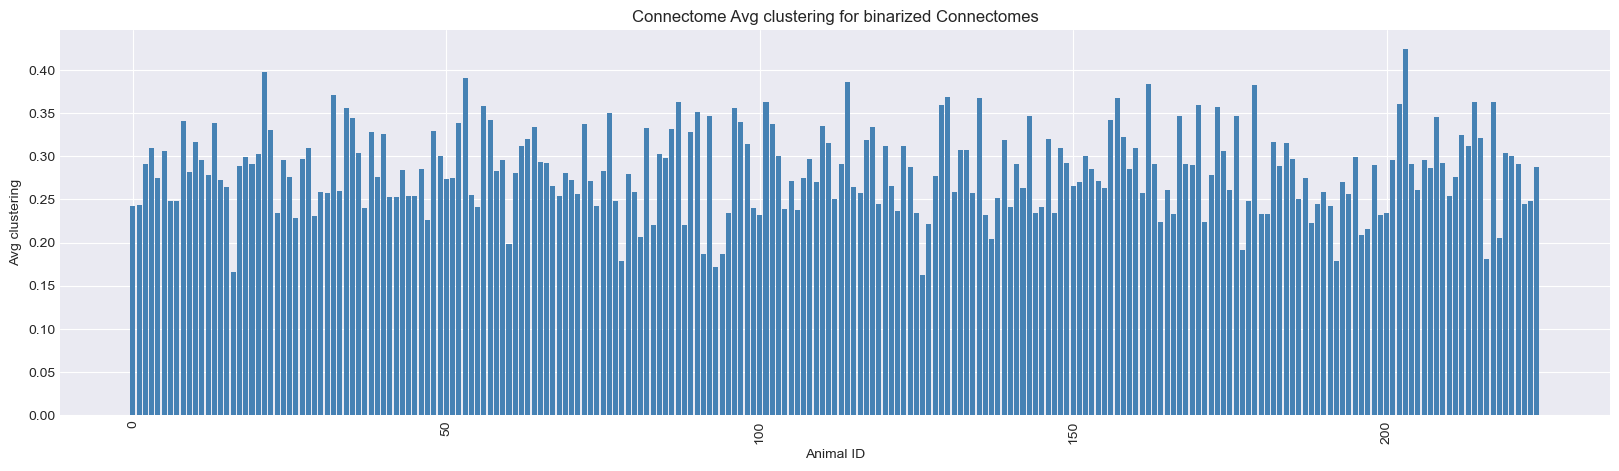

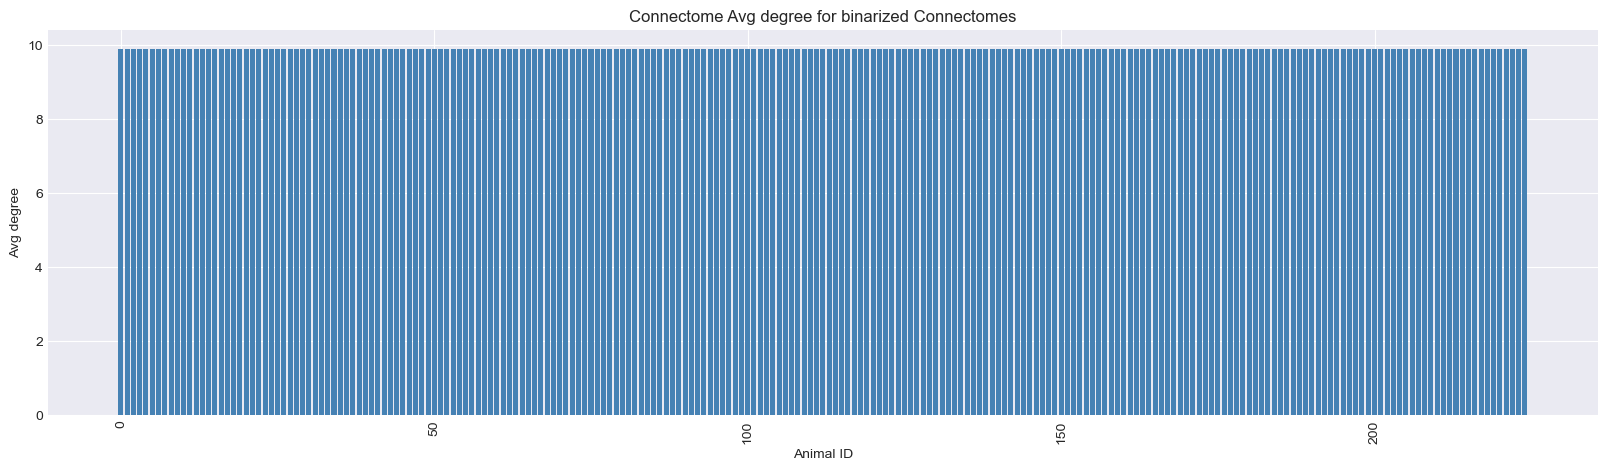

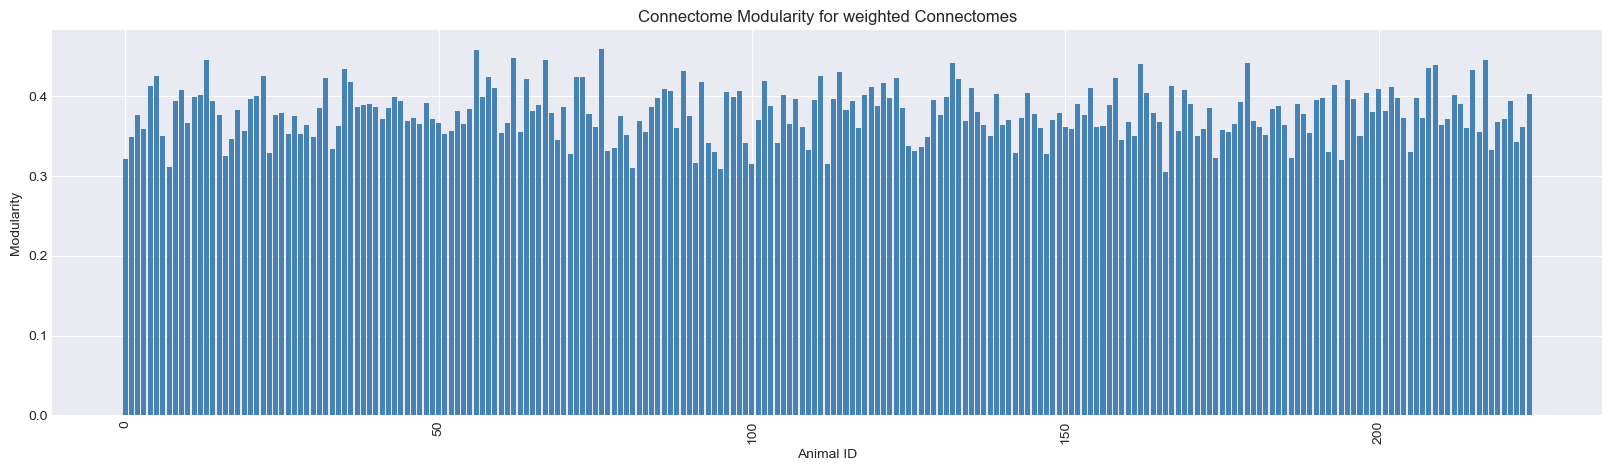

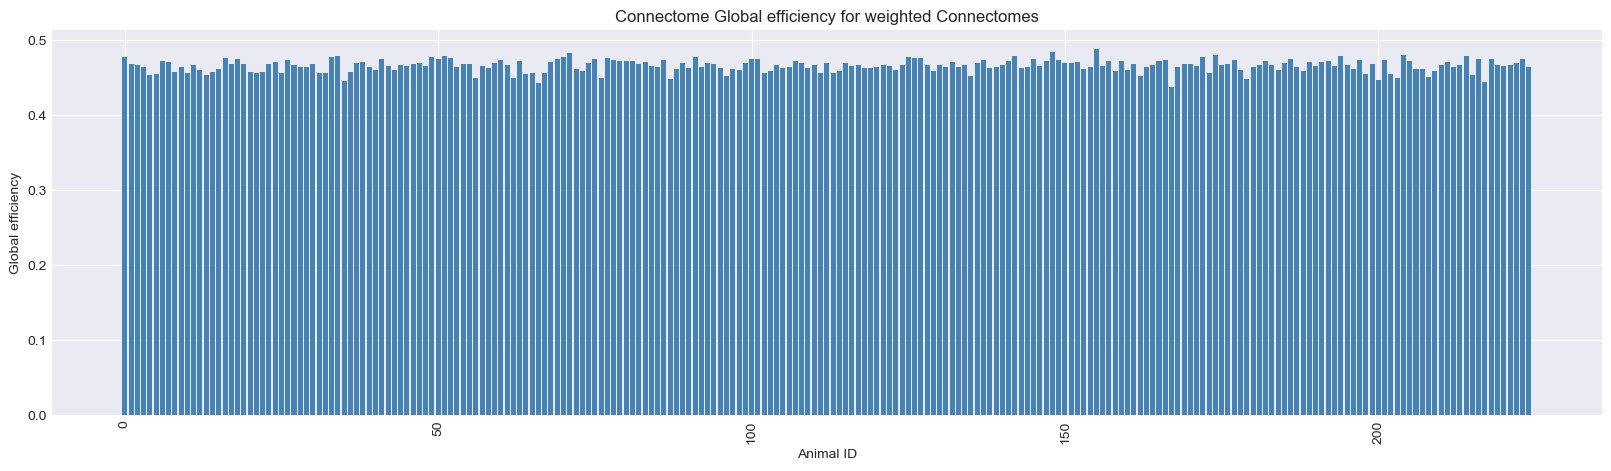

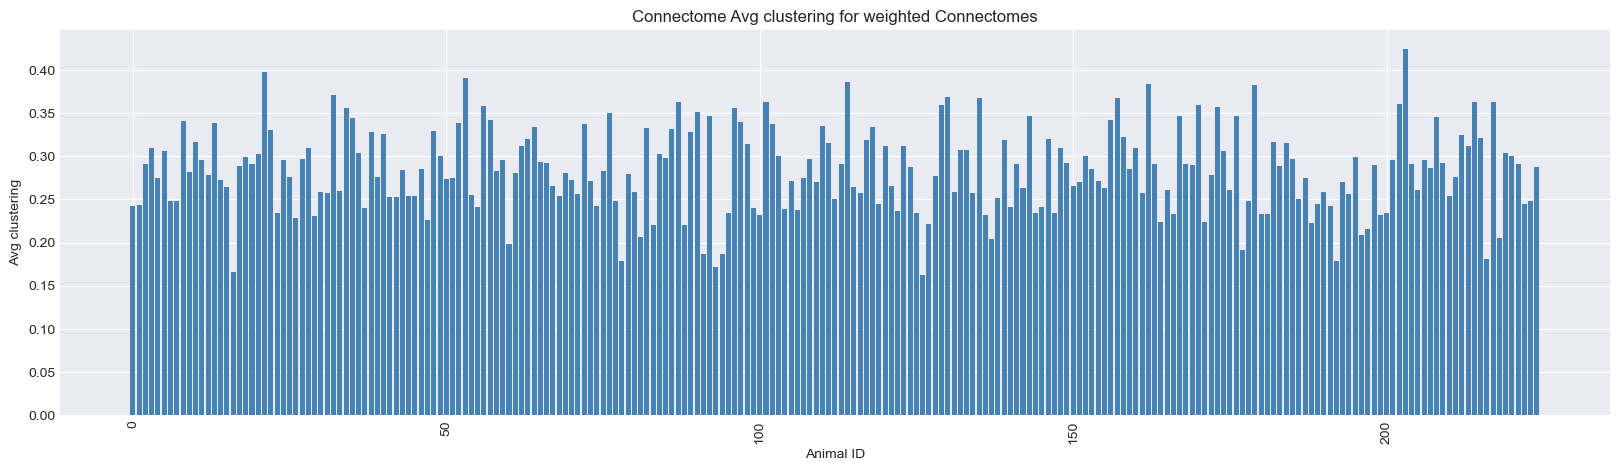

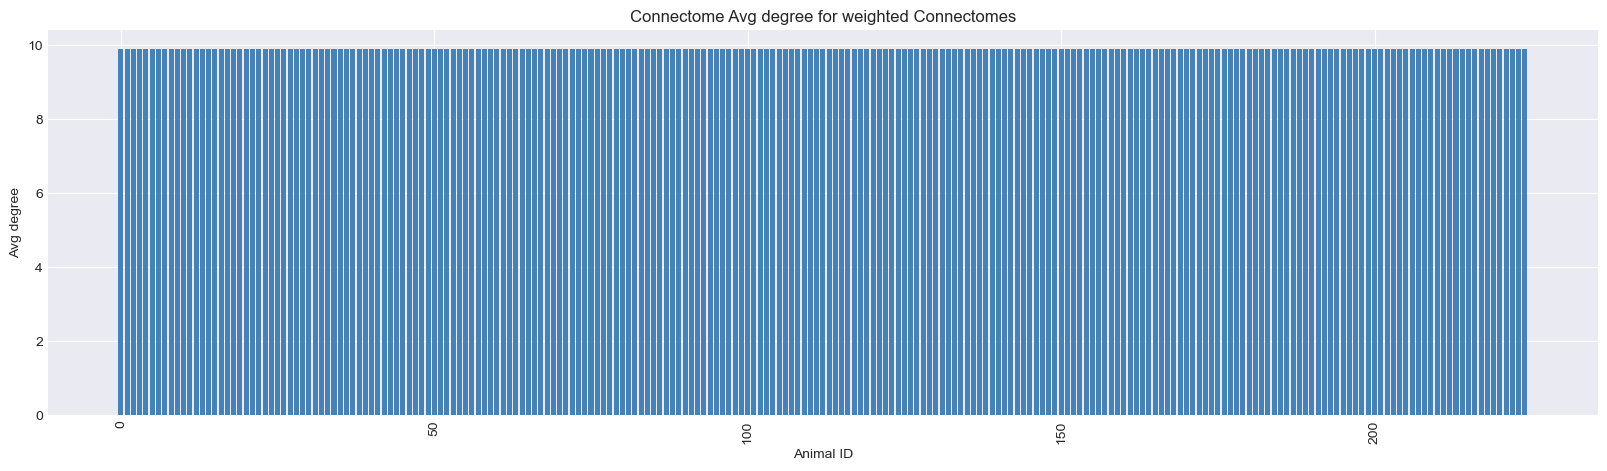

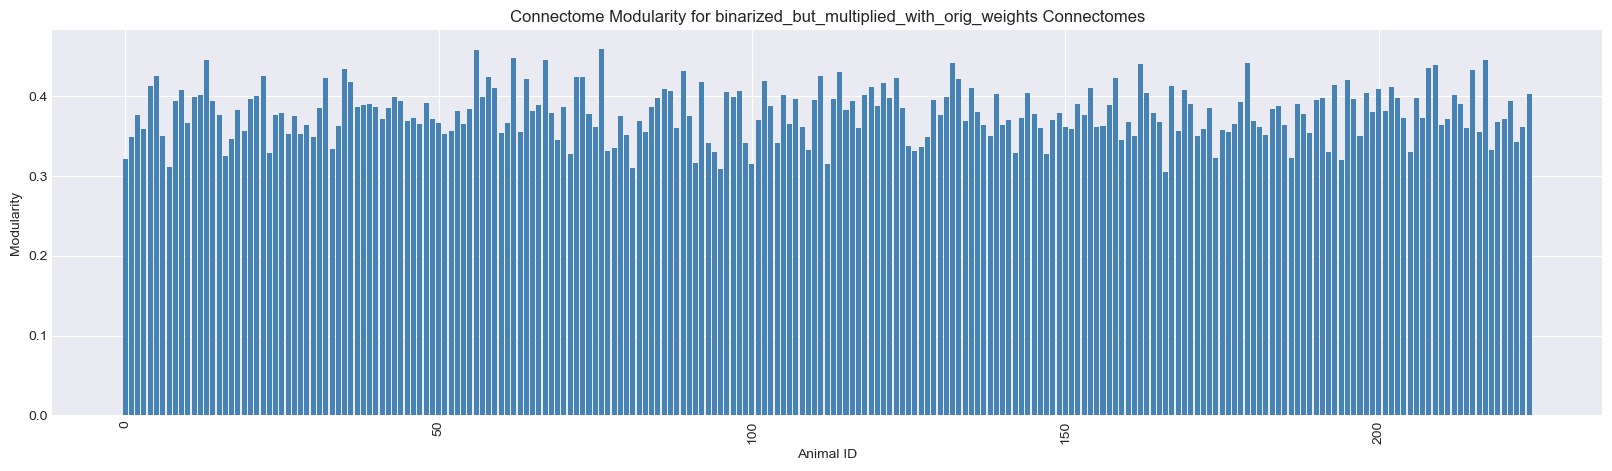

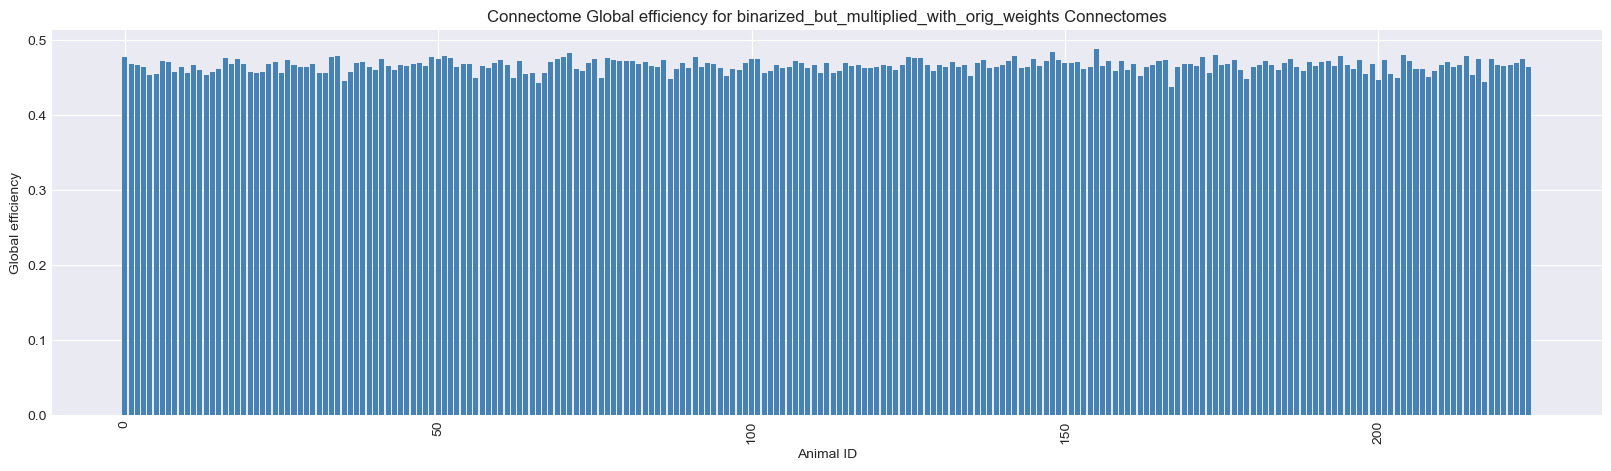

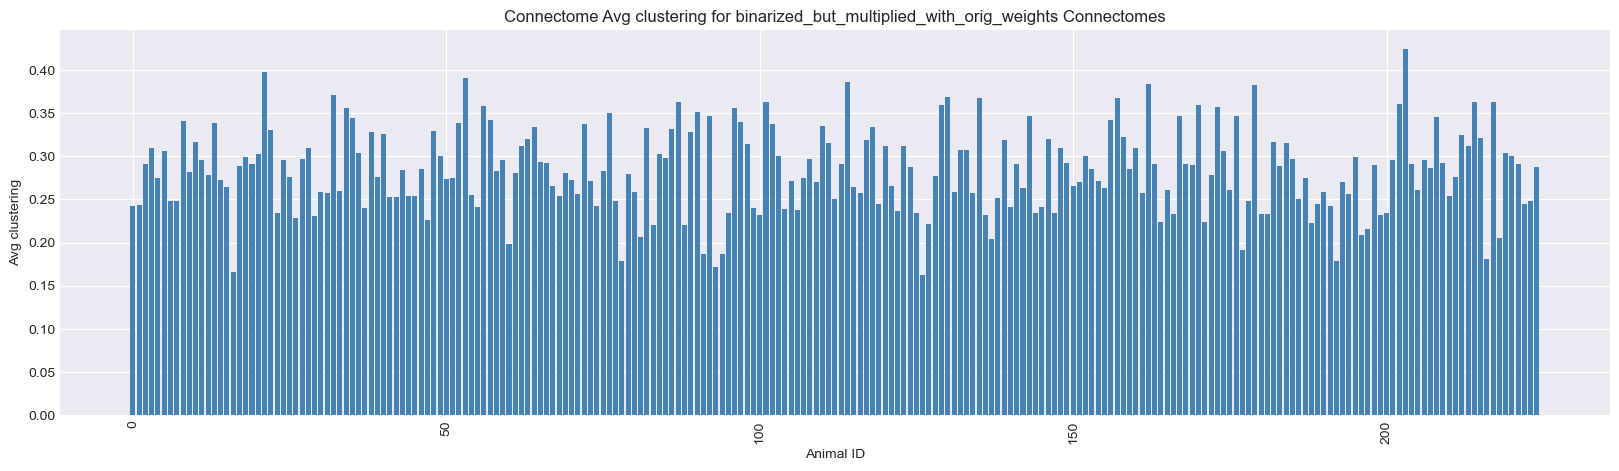

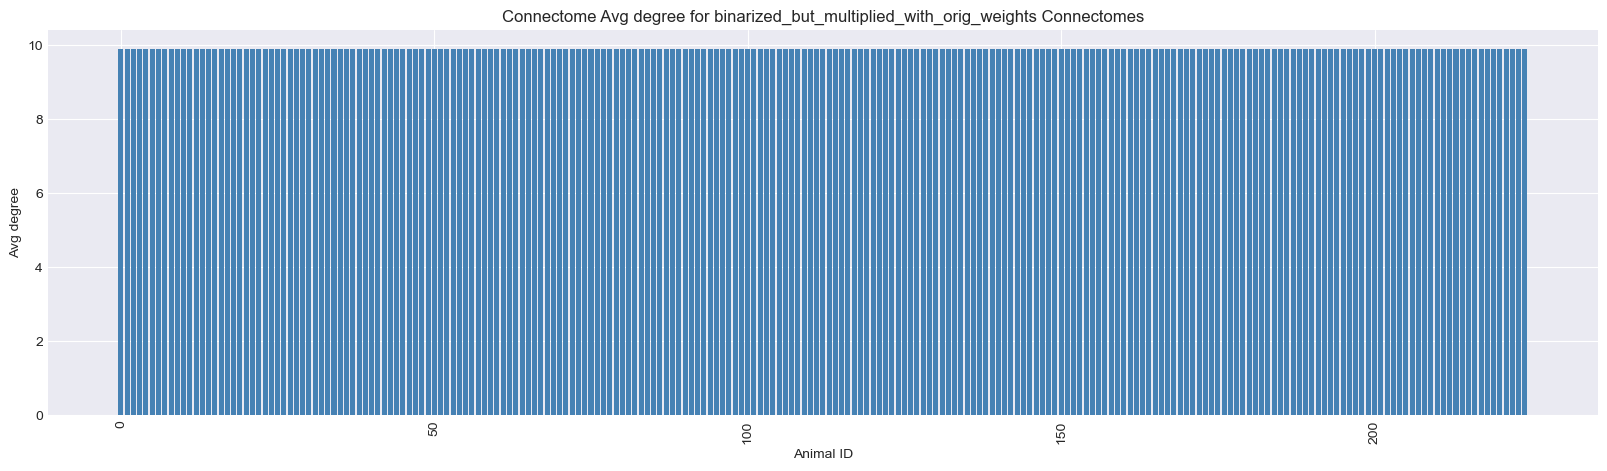

In [22]:
name_dataset_types = ["binarized", "weighted", "binarized_but_multiplied_with_orig_weights"]

for name in name_dataset_types: 

    folder_path = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/emprirical_analysis")
    df = pd.read_csv(folder_path / f"empirical_analysis_{name}.csv")

    for name_metric in ["modularity", "global_efficiency", "avg_clustering", "avg_degree"]:
        plt.figure(figsize=(20,5)) 
        plt.bar(df['subject_id'], df[name_metric], color='steelblue')
        plt.xlabel('Animal ID')
        plt.ylabel(name_metric.replace('_', ' ').capitalize())
        plt.title(f'Connectome {name_metric.replace('_', ' ').capitalize()} for {name} Connectomes')
        plt.xticks(rotation=90)
        plt.savefig(folder_path / f"{name_metric}_barplot_{name}.pdf")

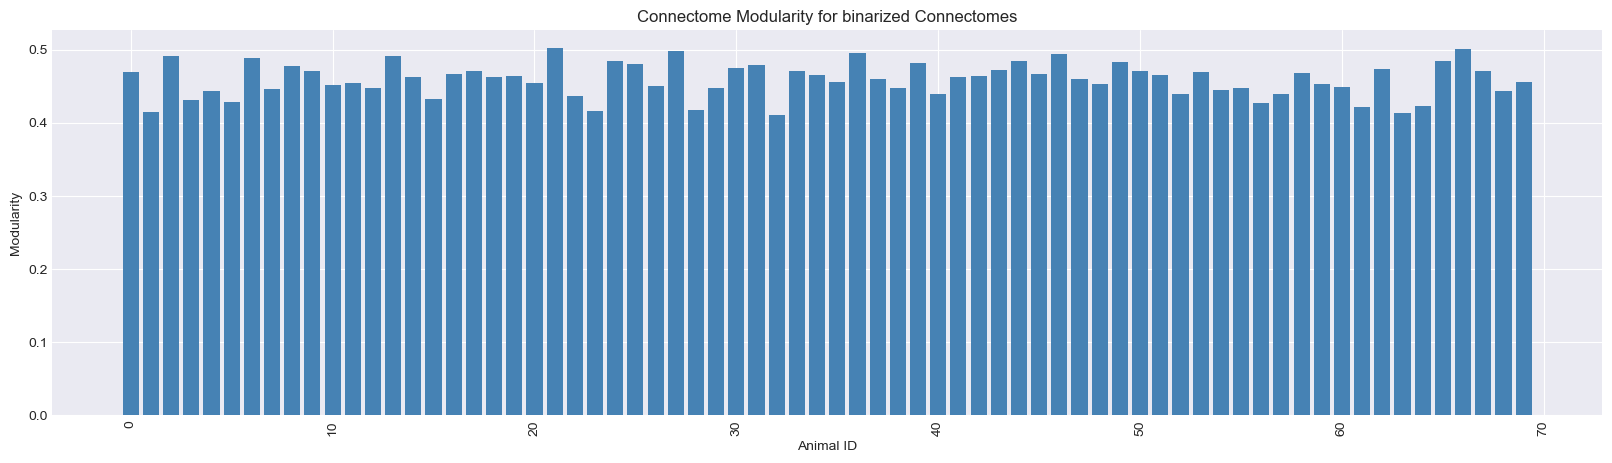

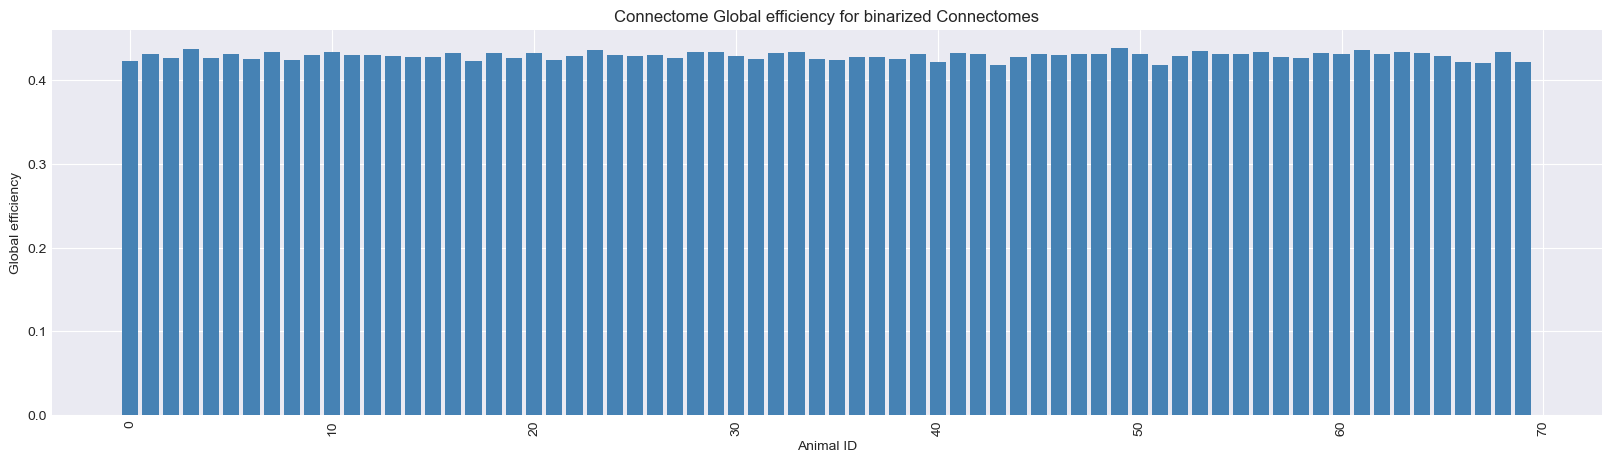

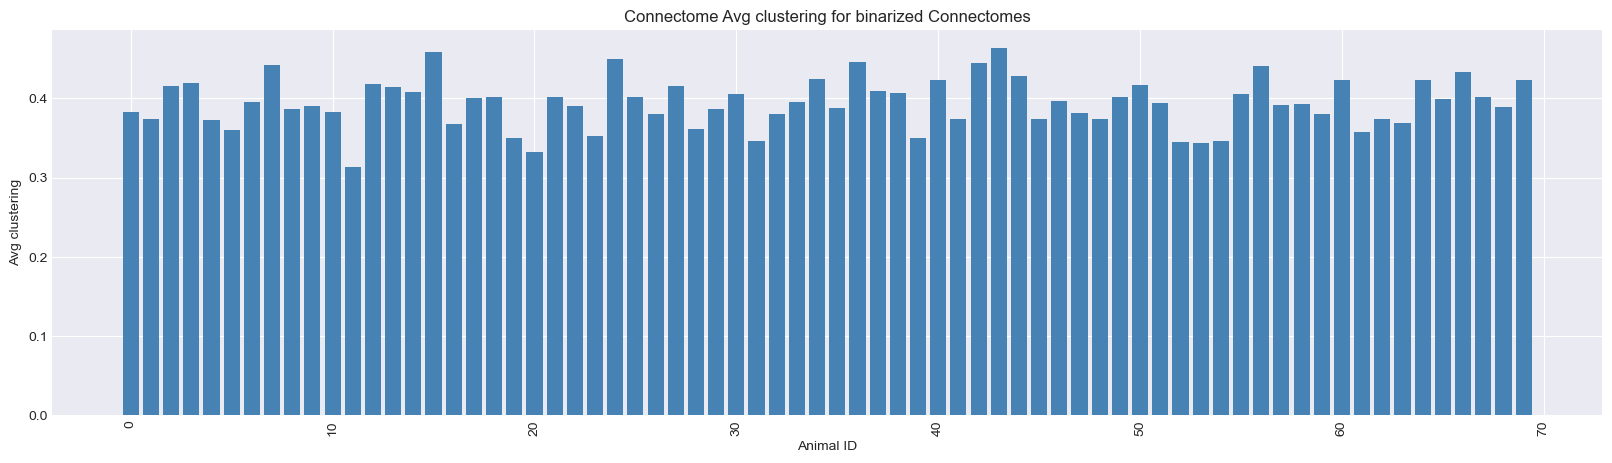

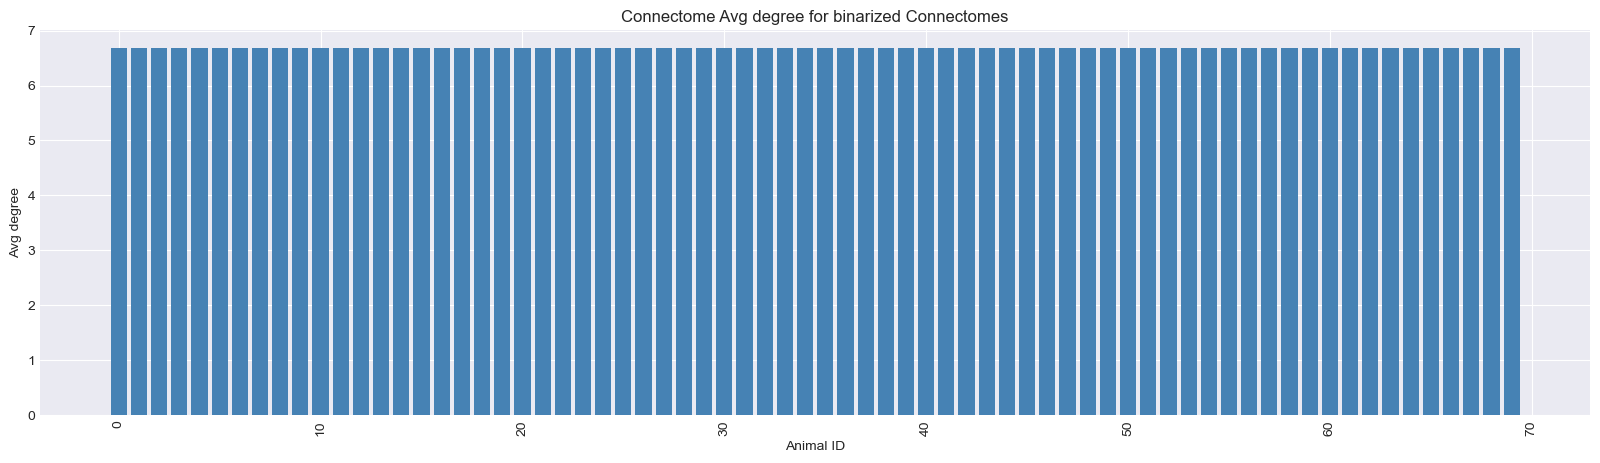

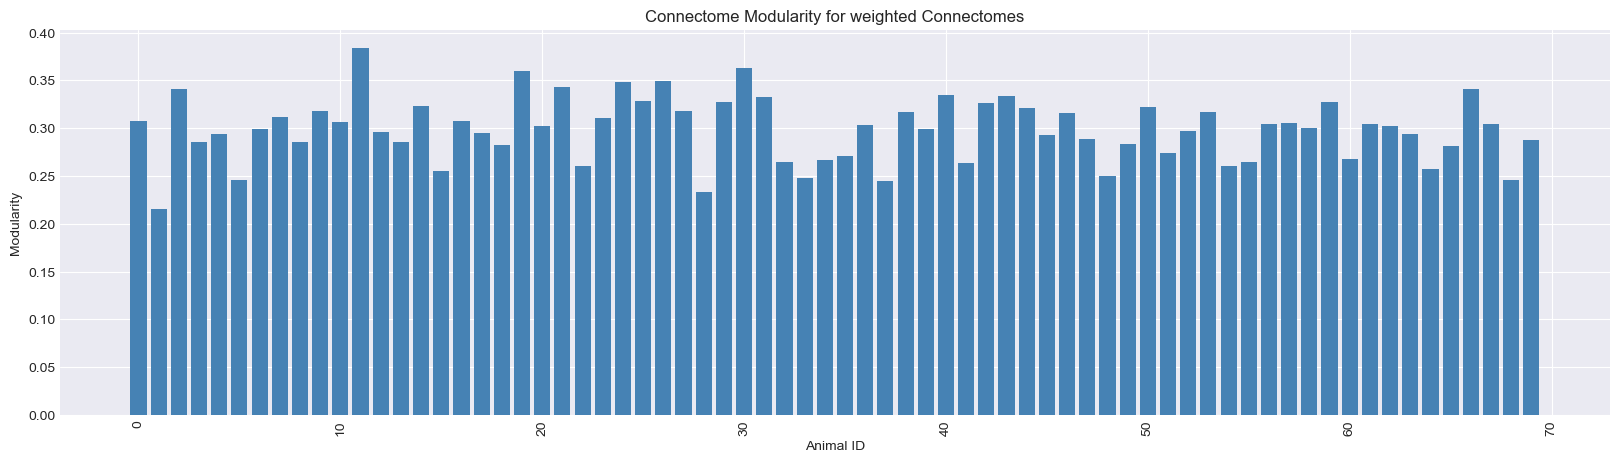

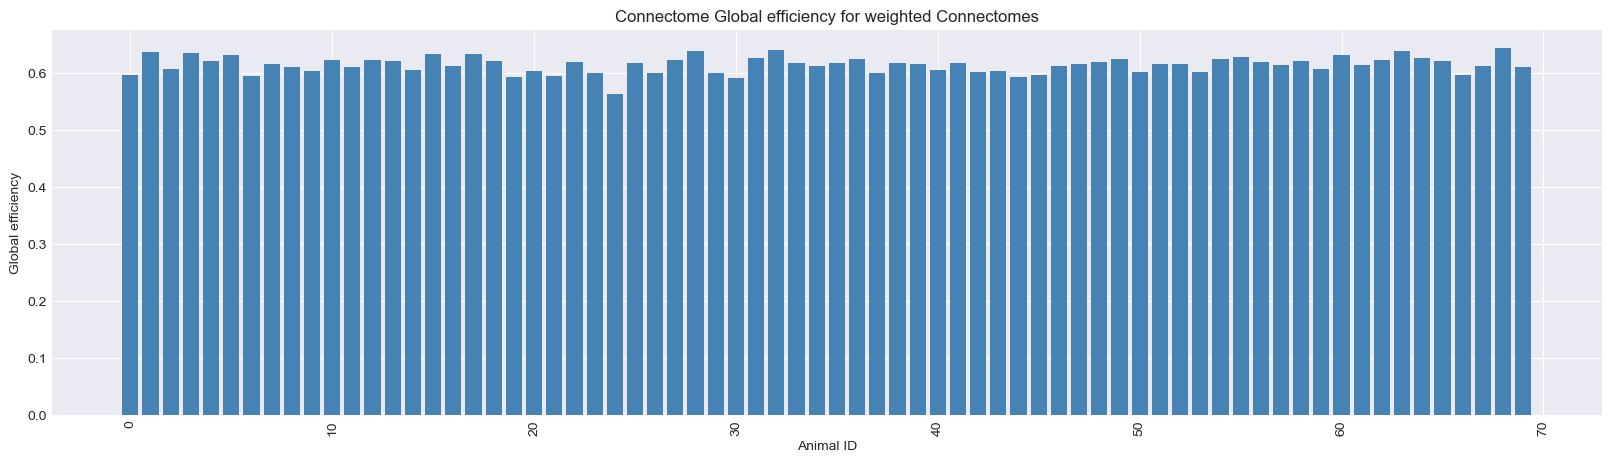

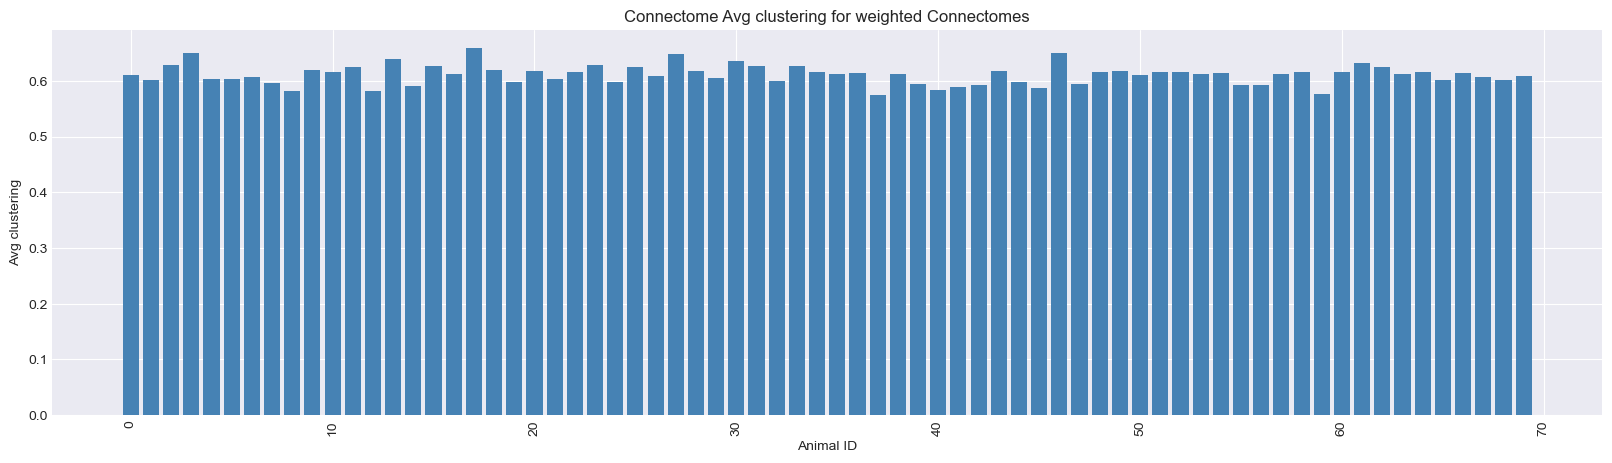

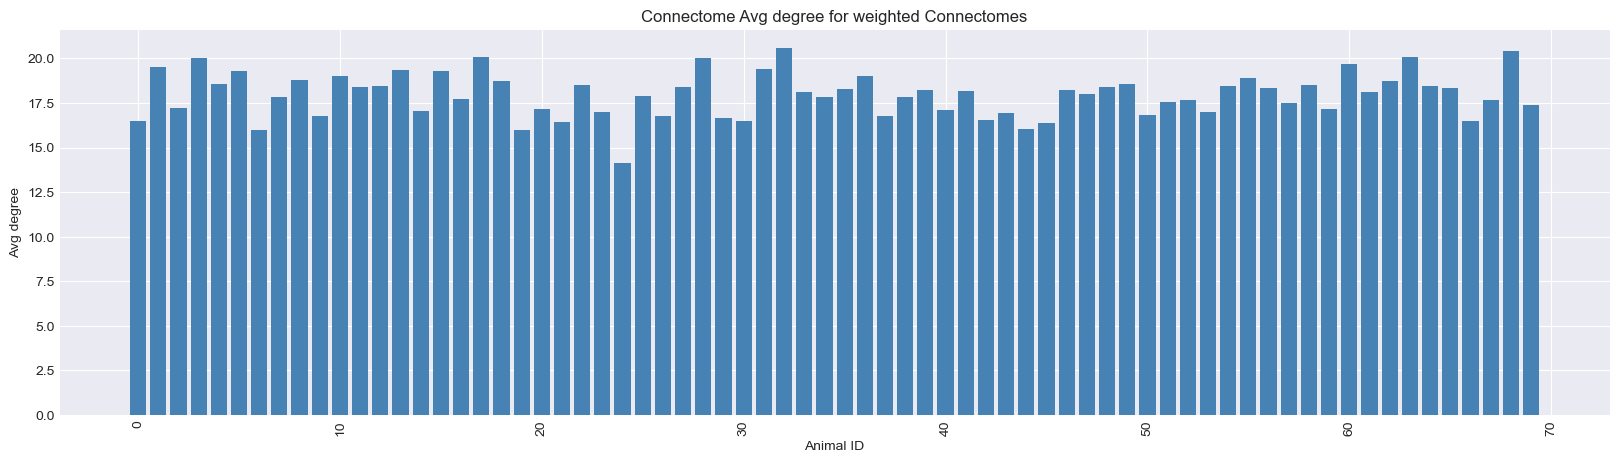

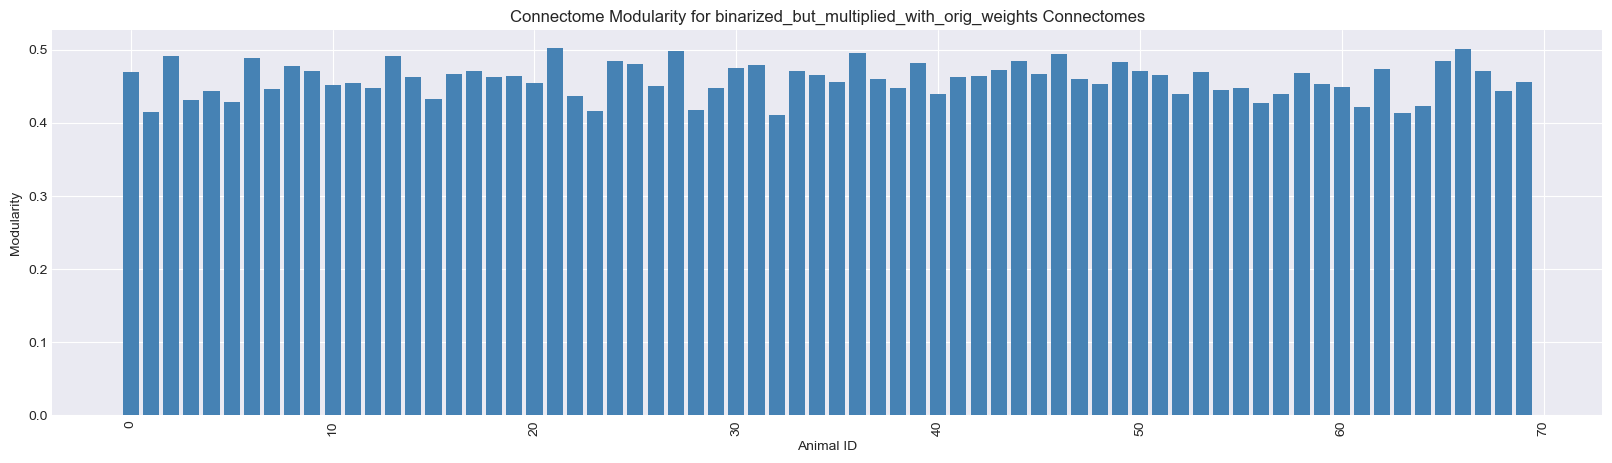

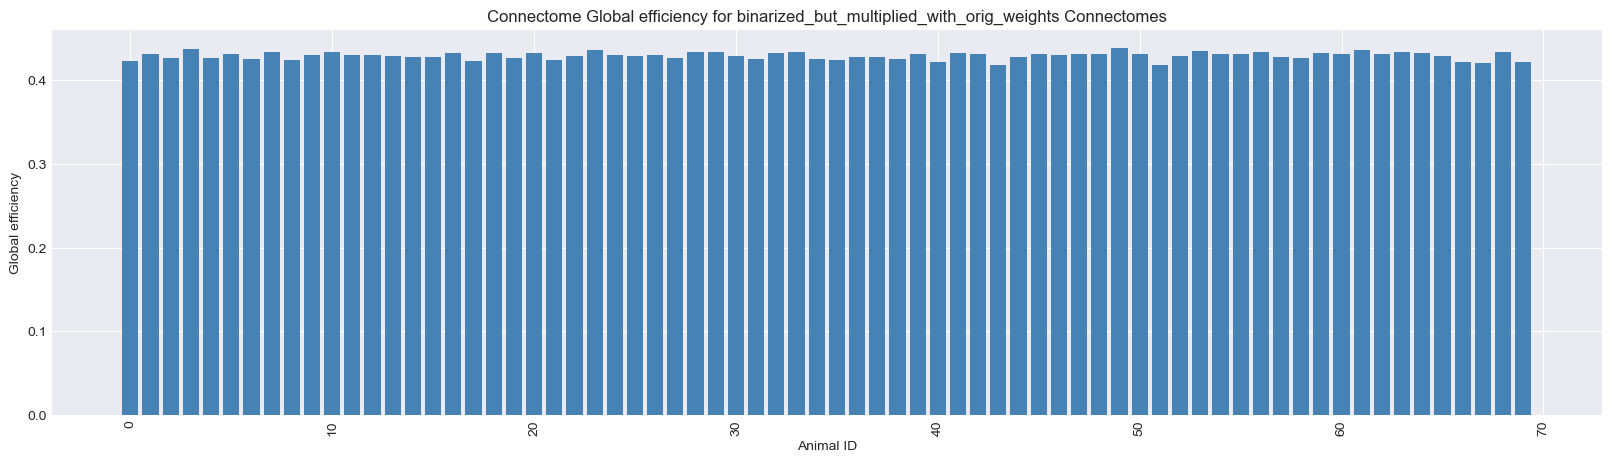

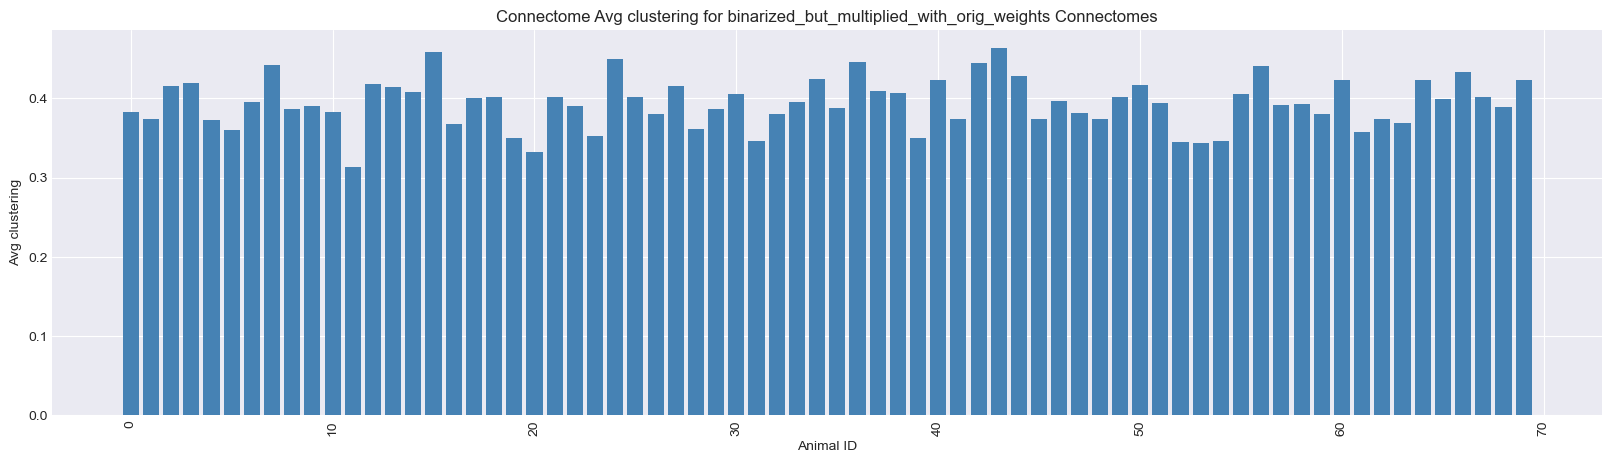

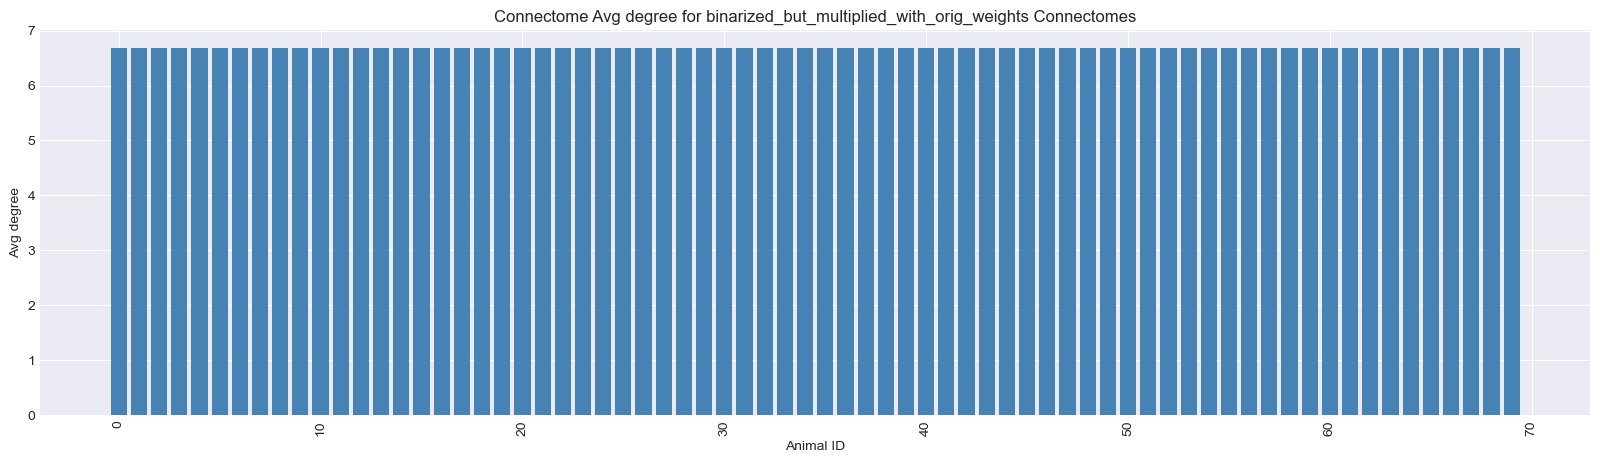

In [23]:
name_dataset_types = ["binarized", "weighted", "binarized_but_multiplied_with_orig_weights"]

for name in name_dataset_types: 

    folder_path = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/old_emprirical_analysis") 
    # /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/emprirical_analysis")
    df = pd.read_csv(folder_path / f"empirical_analysis_{name}.csv")

    for name_metric in ["modularity", "global_efficiency", "avg_clustering", "avg_degree"]:
        plt.figure(figsize=(20,5)) 
        plt.bar(df['subject_id'], df[name_metric], color='steelblue')
        plt.xlabel('Animal ID')
        plt.ylabel(name_metric.replace('_', ' ').capitalize())
        plt.title(f'Connectome {name_metric.replace('_', ' ').capitalize()} for {name} Connectomes')
        plt.xticks(rotation=90)
        plt.savefig(folder_path / f"{name_metric}_barplot_{name}.pdf")